In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_squared_error

In [82]:
df = pd.read_csv("/content/Dow Jones Industrial Average Historical Data.csv")

In [83]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Dec 31, 2019","28,538.44","28,414.64","28,547.35","28,376.49",193.34M,0.27%
1,"Dec 30, 2019","28,462.14","28,654.76","28,664.69","28,428.98",185.07M,-0.64%
2,"Dec 27, 2019","28,645.26","28,675.34","28,701.66","28,608.98",184.93M,0.08%
3,"Dec 26, 2019","28,621.39","28,539.46","28,624.10","28,535.15",155.97M,0.37%
4,"Dec 24, 2019","28,515.45","28,572.57","28,576.80","28,503.21",95.29M,-0.13%


In [84]:
# Convert to numeric
df['Price'] = df['Price'].str.replace(',', '').astype(float)

In [85]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Dec 31, 2019",28538.44,"28,414.64","28,547.35","28,376.49",193.34M,0.27%
1,"Dec 30, 2019",28462.14,"28,654.76","28,664.69","28,428.98",185.07M,-0.64%
2,"Dec 27, 2019",28645.26,"28,675.34","28,701.66","28,608.98",184.93M,0.08%
3,"Dec 26, 2019",28621.39,"28,539.46","28,624.10","28,535.15",155.97M,0.37%
4,"Dec 24, 2019",28515.45,"28,572.57","28,576.80","28,503.21",95.29M,-0.13%


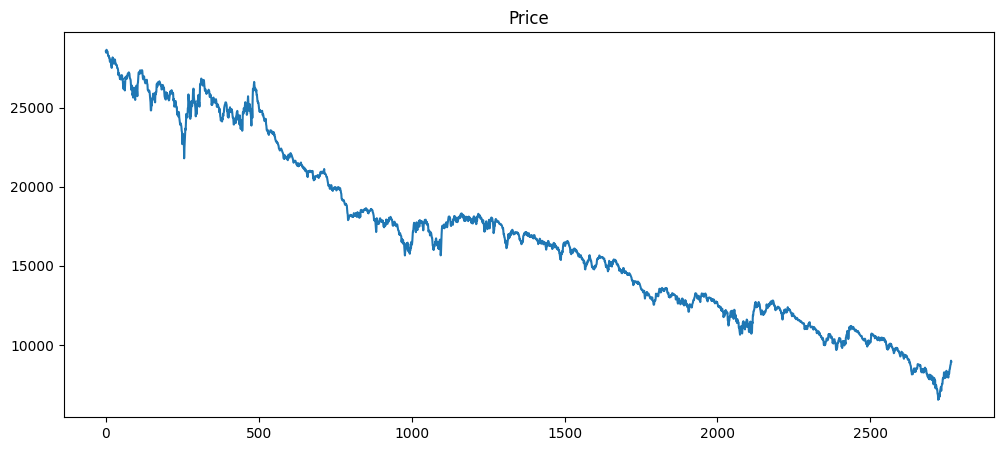

In [86]:
plt.figure(figsize=(12,5))
plt.plot(df['Price'])
plt.title("Price")
plt.show()

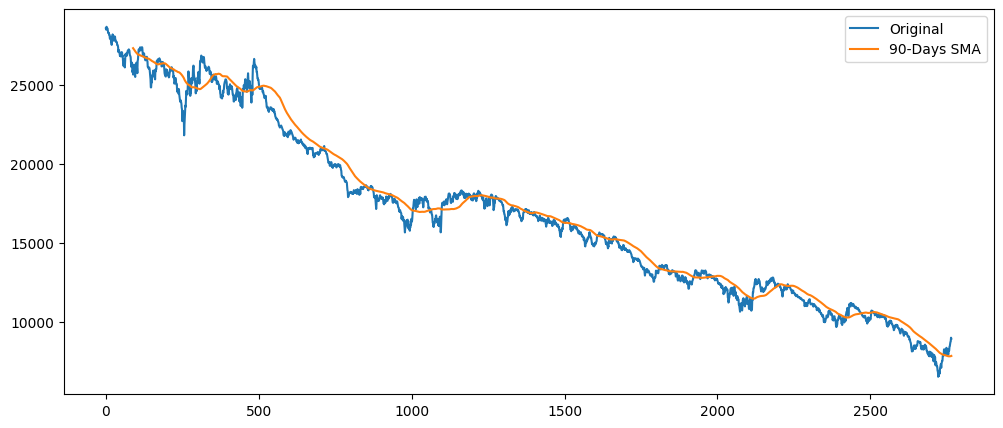

In [87]:
df['SMA_90'] = df['Price'].rolling(window=90).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Price'], label='Original')
plt.plot(df['SMA_90'], label='90-Days SMA')
plt.legend()
plt.show()

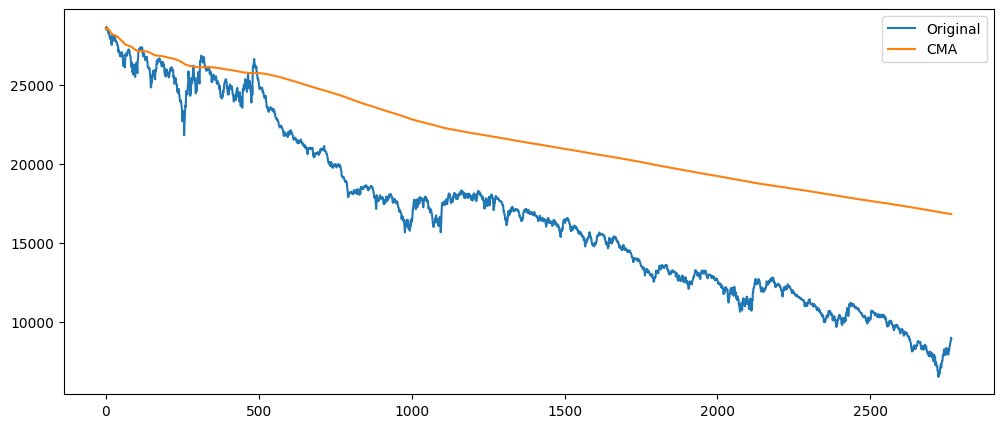

In [88]:
df['CMA'] = df['Price'].expanding().mean()

plt.figure(figsize=(12,5))
plt.plot(df['Price'], label='Original')
plt.plot(df['CMA'], label='CMA')
plt.legend()
plt.show()

In [89]:
df.head(20)

,Date,Price,Open,High,Low,Vol.,Change %,SMA_90,CMA
0,"Dec 31, 2019",28538.44,"28,414.64","28,547.35","28,376.49",193.34M,0.27%,NaN,28538.440000
1,"Dec 30, 2019",28462.14,"28,654.76","28,664.69","28,428.98",185.07M,-0.64%,NaN,28500.290000
2,"Dec 27, 2019",28645.26,"28,675.34","28,701.66","28,608.98",184.93M,0.08%,NaN,28548.613333
3,"Dec 26, 2019",28621.39,"28,539.46","28,624.10","28,535.15",155.97M,0.37%,NaN,28566.807500
4,"Dec 24, 2019",28515.45,"28,572.57","28,576.80","28,503.21",95.29M,-0.13%,NaN,28556.536000
5,"Dec 23, 2019",28551.53,"28,491.78","28,582.49","28,491.78",233.47M,0.34%,NaN,28555.701667
6,"Dec 20, 2019",28455.09,"28,608.64","28,608.64","28,445.60",603.78M,0.28%,NaN,28541.328571
7,"Dec 19, 2019",28376.96,"28,278.31","28,381.48","28,278.24",262.57M,0.49%,NaN,28520.782500
8,"Dec 18, 2019",28239.28,"28,291.44","28,323.25","28,239.28",289.89M,-0.10%,NaN,28489.504444
9,"Dec 17, 2019",28267.16,"28,221.75","28,328.63","28,220.56",286.77M,0.11%,NaN,28467.270000


Staitionarity


In [90]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    series = series.dropna()   # IMPORTANT
    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print(" Data is Stationary")
    else:
        print(" Data is NOT Stationary")

adf_test(df['Price'])

ADF Statistic: -1.4699136528073573
p-value: 0.5483386771084665
 Data is NOT Stationary


Its a non stationary data as p value greater than 0.05

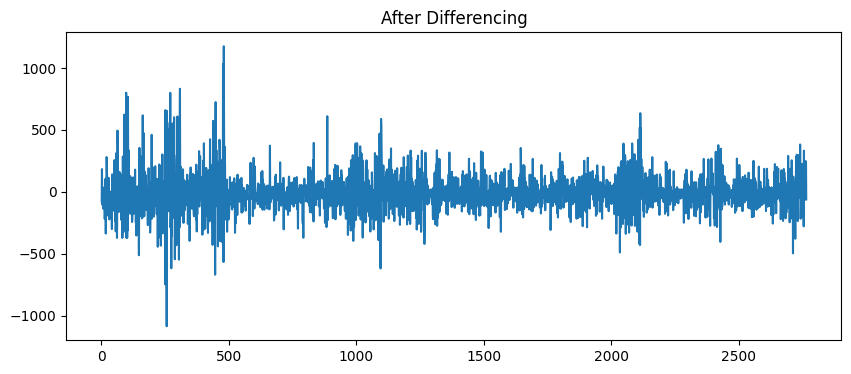

ADF Statistic: -11.13590092055933
p-value: 3.196012715201822e-20
 Data is Stationary


In [91]:
df['diff'] = df['Price'].diff()

plt.figure(figsize=(10,4))
plt.plot(df['diff'])
plt.title("After Differencing")
plt.show()

adf_test(df['diff'])

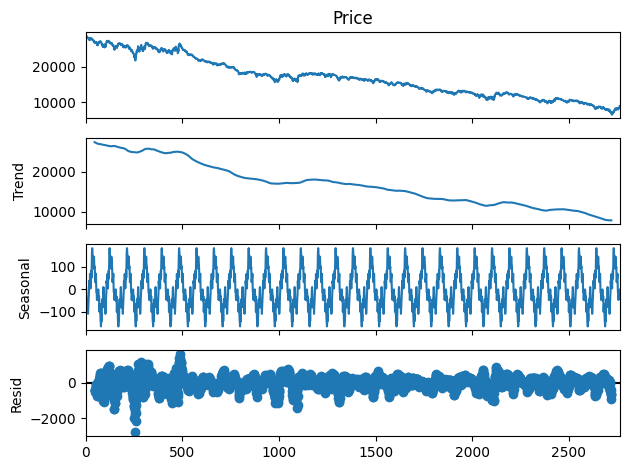

In [92]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Price'], model='additive', period=90)
decomposition.plot()
plt.show()

<Figure size 1000x400 with 0 Axes>

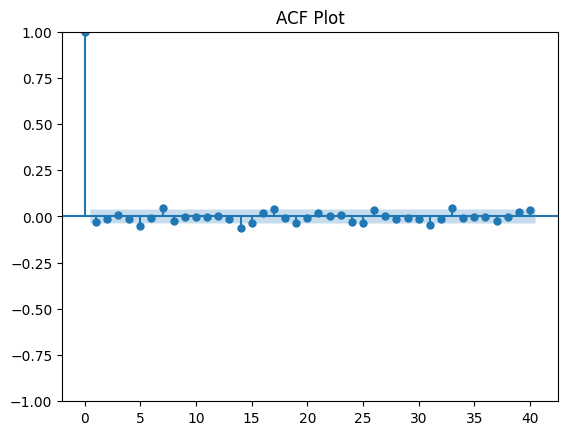

In [93]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df['diff'].dropna(), lags=40)
plt.title("ACF Plot")
plt.show()

<Figure size 1000x400 with 0 Axes>

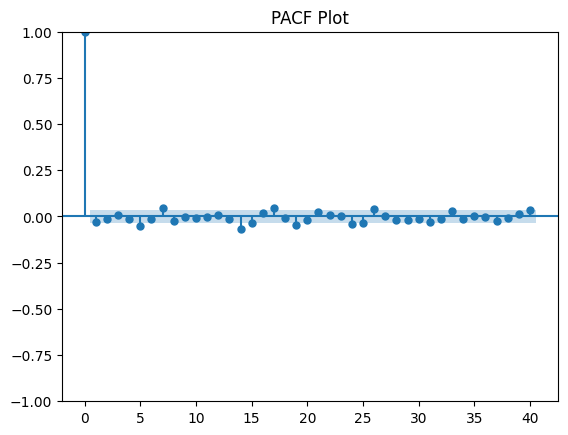

In [94]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(df['diff'].dropna(), lags=40)
plt.title("PACF Plot")
plt.show()

In [95]:
split = int(len(df) * 0.8)

train = df['Price'][:split]
test = df['Price'][split:]

#ARIMA MODEL

In [96]:
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(len(test))

#SARIMA MODEL

In [97]:
model_sarima= SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(1,1,1,7))

model_sarima_fit = model_sarima.fit()

pred_sarima = model_sarima_fit.forecast(len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [98]:
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 2378.992448880968
SARIMA RMSE: 526.3380863494458


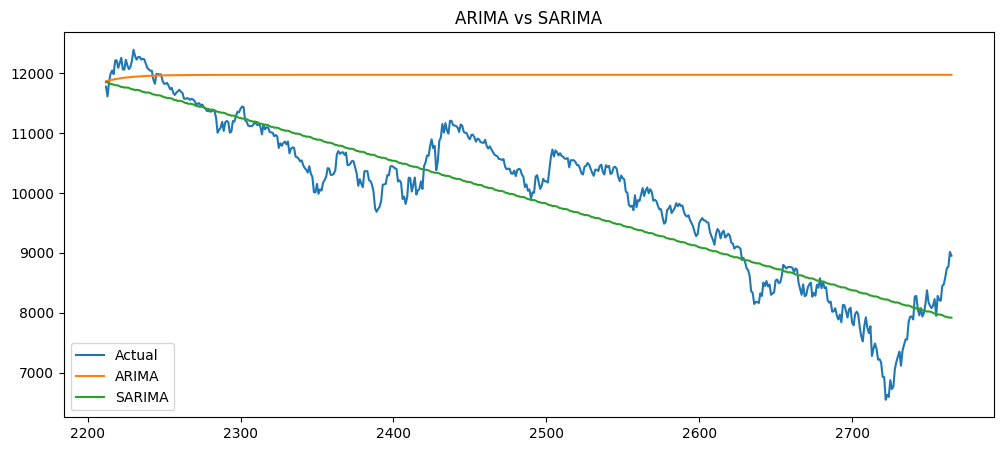

In [99]:
plt.figure(figsize=(12,5))
plt.plot(test, label='Actual')
plt.plot(pred_arima, label='ARIMA')
plt.plot(pred_sarima, label='SARIMA')
plt.legend()
plt.title("ARIMA vs SARIMA")
plt.show()

In [100]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_sarima))
print("Final SARIMA RMSE:", rmse)

Final SARIMA RMSE: 526.3380863494458


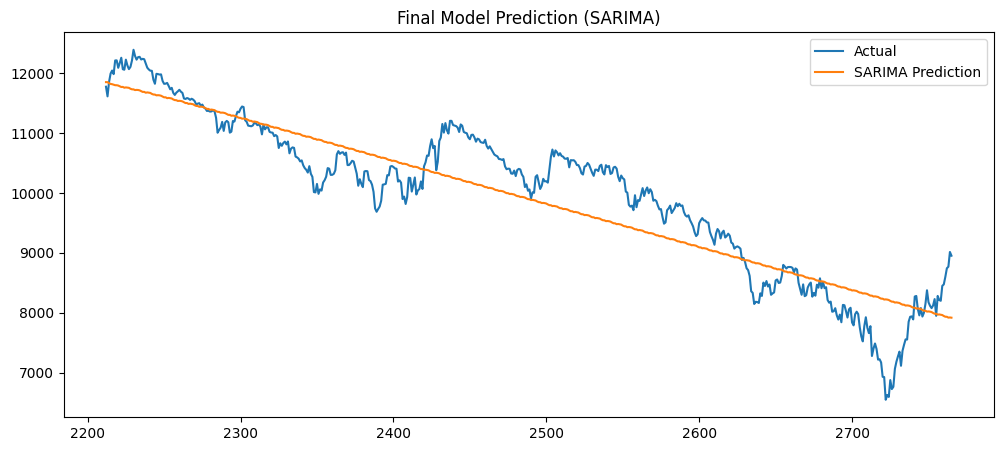

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test, label='Actual')
plt.plot(pred_sarima, label='SARIMA Prediction')

plt.legend()
plt.title("Final Model Prediction (SARIMA)")
plt.show()

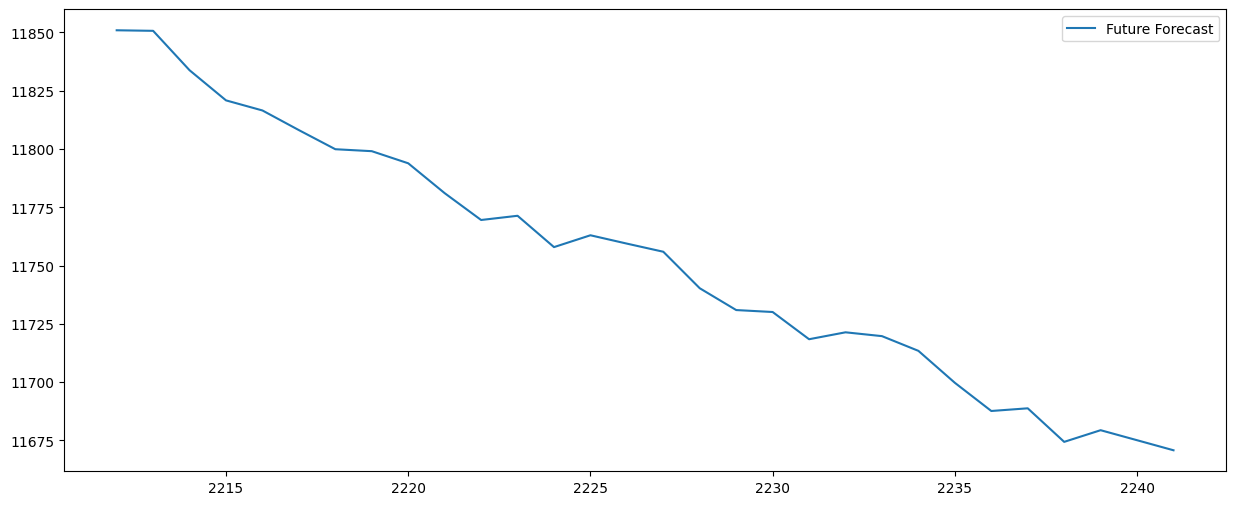

In [102]:
future_pred = model_sarima_fit.forecast(steps=30)

plt.figure(figsize=(15,6))
plt.plot(future_pred, label='Future Forecast')
plt.legend()
plt.show()

👉 About ARIMA:
“ARIMA model produced nearly constant predictions, indicating its inability to capture seasonal variations in the data.”

👉 About SARIMA:
“SARIMA model performed better as it captured both trend and seasonal patterns, resulting in predictions closer to actual values.”